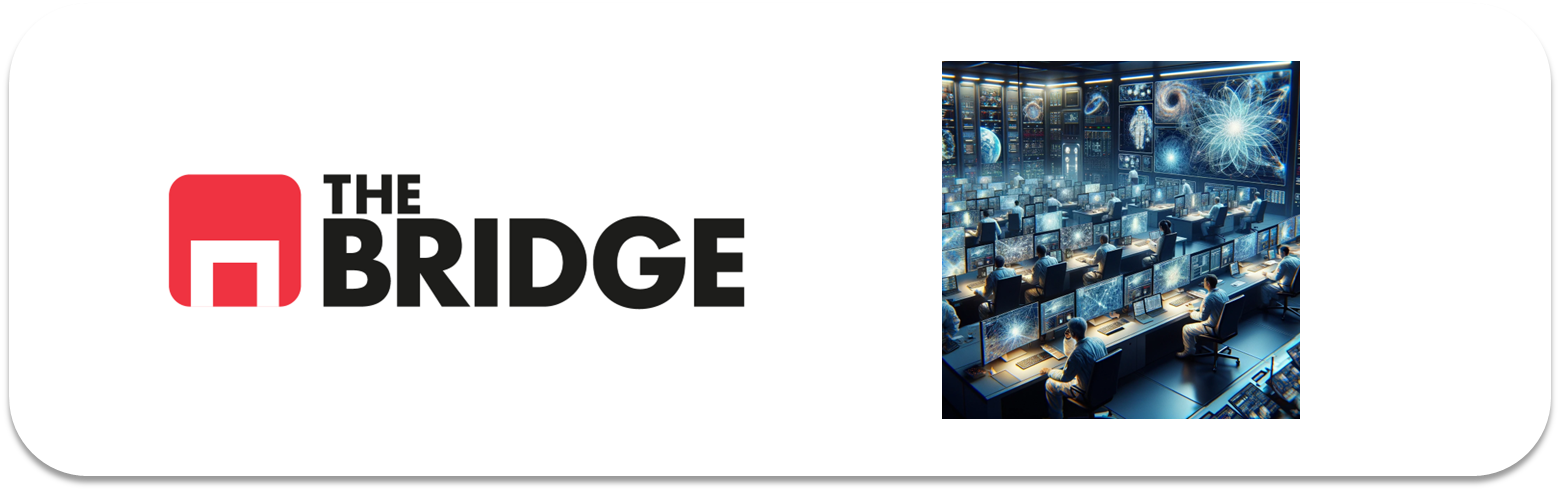

## PRACTICA OBLIGATORIA: **Transfer Learning y Fine Tuning con CNN**

* La práctica obligatoria de esta unidad consiste en un repetir el ejercicio de construcción de un modelo de clasificación de paisajes pero usando un modelo preentrenado. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2, VGG19, InceptionV3
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix
import os
import cv2
import kagglehub
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

c:\Users\MartaEstevez\Documents\PERSONAL\The Bridge curso\DS-Online-Marta-Estevez\bridge-env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Objetivo del ejercicio

Comparar una red convolucional hecha ad-hoc frente a los modelos preentrenados y ajustados con fine tuning y transfer learning. Para ello emplea el dataset de paisajes del conjunto de ejercicios de la unidad anterior.


### Se pide

1. Preparar los datos del modelo y las funciones de visualización, copia para ello todo lo que necesites de las soluciones del ejercicio de clasificación de paisajes de la unidad anterior.

2. Escoger entre uno de los modelos VGG-19, InceptionV3 y MobileNetV2 (todos en https://keras.io/api/applications/) (Se aconseja este último si no tenemos un ordenador muy potente). Si no te haces con estos puedes recurrir a la ResNetV50.

4. Hacer un transfer-learning con una cabeza de como mucho 2 capas densas ocultas y una de salida. Mostrar la evaluación contra test, el report de clasificación y la matriz de confusión.

5. Hacer un fine-tuning con la misma cabeza diseñada en el punto anterior. Mostrar la evaluación contra test, el report de clasificación y la matriz de confusión.

6. Comparar los resultados con los obtenidos con la red convolucional del ejercicio mencionado.

EXTRA:
- Repetir el transfer learning empleando aumentado de imágenes.



### Preparación de los datos

In [4]:
print("Descargando dataset de Kaggle...")
path = kagglehub.dataset_download("puneet6060/intel-image-classification")
print(f"Dataset descargado en: {path}")

# Guardar la ruta
DATASET_PATH = path

Descargando dataset de Kaggle...
Dataset descargado en: C:\Users\MartaEstevez\.cache\kagglehub\datasets\puneet6060\intel-image-classification\versions\2


In [5]:
TRAIN_DIR = os.path.join(DATASET_PATH, 'seg_train', 'seg_train')
TEST_DIR = os.path.join(DATASET_PATH, 'seg_test', 'seg_test')

print(f"Train dir: {TRAIN_DIR}")
print(f"Test dir: {TEST_DIR}")

# Parámetros
IMG_SIZE = (224, 224)  # Tamaño para MobileNetV2
BATCH_SIZE = 32

# Generadores de datos
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2  # 20% para validación
)

test_datagen = ImageDataGenerator(rescale=1./255)

# Crear generadores
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Clases
class_names = list(train_generator.class_indices.keys())
num_classes = len(class_names)
print(f"\nClases: {class_names}")
print(f"Número de clases: {num_classes}")

Train dir: C:\Users\MartaEstevez\.cache\kagglehub\datasets\puneet6060\intel-image-classification\versions\2\seg_train\seg_train
Test dir: C:\Users\MartaEstevez\.cache\kagglehub\datasets\puneet6060\intel-image-classification\versions\2\seg_test\seg_test
Found 11230 images belonging to 6 classes.
Found 2804 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.

Clases: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Número de clases: 6


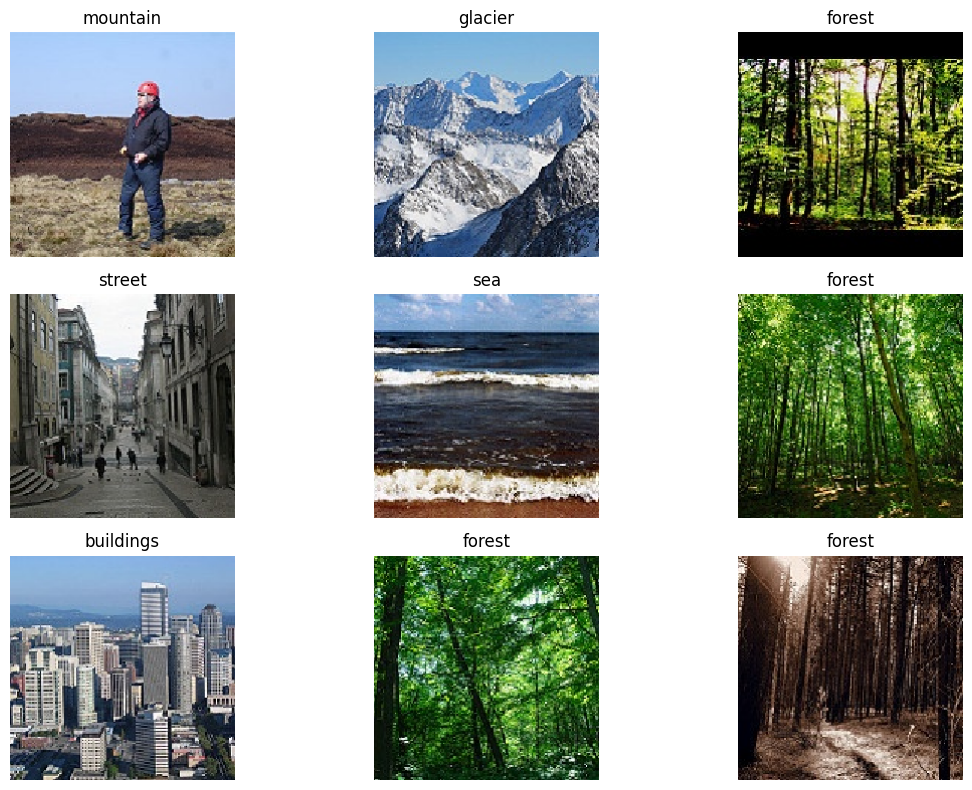

In [6]:
plt.figure(figsize=(12, 8))

images, labels = next(train_generator)

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    class_idx = np.argmax(labels[i])
    plt.title(class_names[class_idx])
    plt.axis('off')

plt.tight_layout()
plt.show()

In [7]:

base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

# Congelar el modelo base
base_model.trainable = False

# Construir modelo
model_tl = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

# Compilar
model_tl.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Modelo Transfer Learning:")
model_tl.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Modelo Transfer Learning:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Cargamos el modelo preentrenado de NobileNetV2

In [8]:
print("Entrenando Transfer Learning...")

history_tl = model_tl.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[EarlyStopping(patience=3, restore_best_weights=True)]
)

print("\n✓ Entrenamiento completado!")

Entrenando Transfer Learning...
Epoch 1/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 169s 473ms/step - accuracy: 0.8641 - loss: 0.3602 - val_accuracy: 0.9058 - val_loss: 0.2602
Epoch 2/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 117s 333ms/step - accuracy: 0.9077 - loss: 0.2490 - val_accuracy: 0.9119 - val_loss: 0.2412
Epoch 3/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 194s 553ms/step - accuracy: 0.9168 - loss: 0.2169 - val_accuracy: 0.9123 - val_loss: 0.2387
Epoch 4/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 179s 511ms/step - accuracy: 0.9300 - loss: 0.1860 - val_accuracy: 0.9030 - val_loss: 0.2619
Epoch 5/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 193s 551ms/step - accuracy: 0.9322 - loss: 0.1771 - val_accuracy: 0.9173 - val_loss: 0.2457
Epoch 6/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 192s 547ms/step - accuracy: 0.9427 - loss: 0.1537 - val_accuracy: 0.9169 - val_loss: 0.2414

✓ Entrenamiento completado!


Evaluando Transfer Learning...
94/94 ━━━━━━━━━━━━━━━━━━━━ 80s 851ms/step - accuracy: 0.9110 - loss: 0.2293

Test Accuracy: 0.9110
94/94 ━━━━━━━━━━━━━━━━━━━━ 51s 508ms/step

Classification Report:
              precision    recall  f1-score   support

   buildings       0.90      0.95      0.93       437
      forest       0.98      0.99      0.99       474
     glacier       0.85      0.83      0.84       553
    mountain       0.83      0.85      0.84       525
         sea       0.96      0.95      0.95       510
      street       0.95      0.91      0.93       501

    accuracy                           0.91      3000
   macro avg       0.91      0.91      0.91      3000
weighted avg       0.91      0.91      0.91      3000



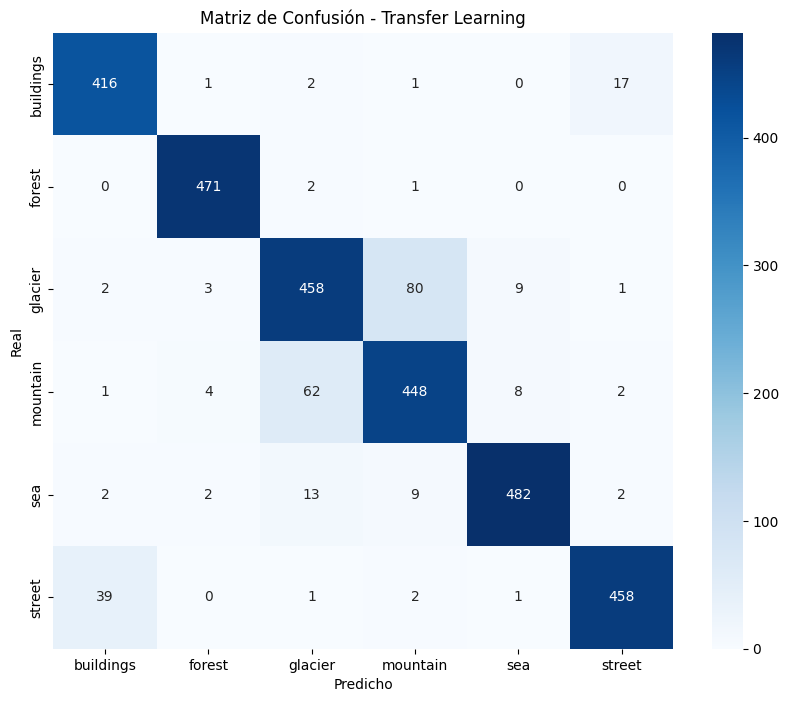

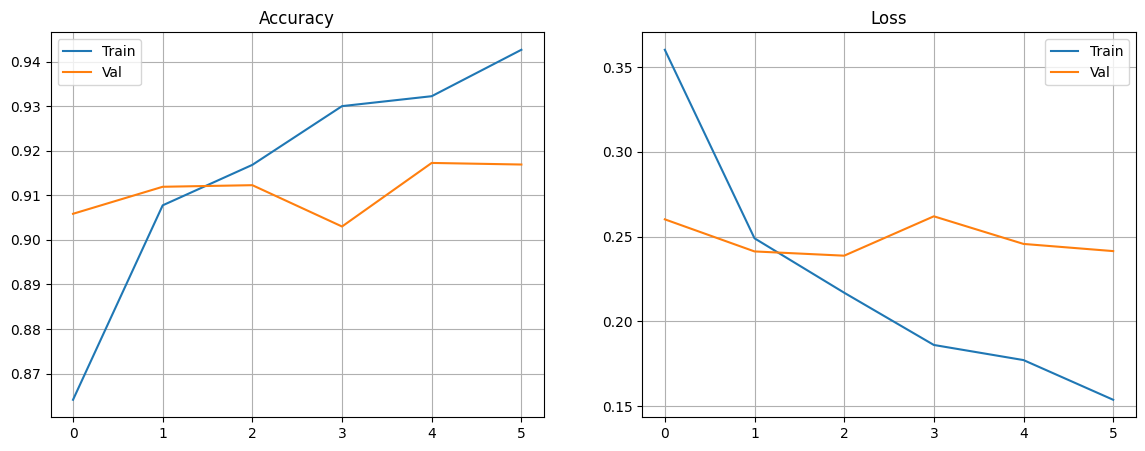

In [9]:
print("Evaluando Transfer Learning...")

test_loss_tl, test_acc_tl = model_tl.evaluate(test_generator)
print(f"\nTest Accuracy: {test_acc_tl:.4f}")

# Predicciones
y_pred = model_tl.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes, target_names=class_names))

# Matriz de confusión
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusión - Transfer Learning')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.show()

# Gráficas de entrenamiento
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history_tl.history['accuracy'], label='Train')
ax1.plot(history_tl.history['val_accuracy'], label='Val')
ax1.set_title('Accuracy')
ax1.legend()
ax1.grid(True)

ax2.plot(history_tl.history['loss'], label='Train')
ax2.plot(history_tl.history['val_loss'], label='Val')
ax2.set_title('Loss')
ax2.legend()
ax2.grid(True)

plt.show()

In [10]:

base_model_ft = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

# Descongelar las últimas 20 capas
base_model_ft.trainable = True
for layer in base_model_ft.layers[:-20]:
    layer.trainable = False

print(f"Capas entrenables: {sum([l.trainable for l in base_model_ft.layers])}")

# Construir modelo
model_ft = Sequential([
    base_model_ft,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

# Compilar con learning rate más bajo
model_ft.compile(
    optimizer=Adam(learning_rate=0.0001),  # LR más bajo
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\nModelo Fine Tuning:")
model_ft.summary()

Capas entrenables: 20

Modelo Fine Tuning:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 1,370,822 (5.23 MB)

 Non-trainable params: 1,051,904 (4.01 MB)

In [11]:
print("Entrenando Fine Tuning...")

history_ft = model_ft.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[EarlyStopping(patience=3, restore_best_weights=True)]
)

print("\n✓ Fine Tuning completado!")

Entrenando Fine Tuning...
Epoch 1/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 241s 670ms/step - accuracy: 0.8539 - loss: 0.4094 - val_accuracy: 0.7996 - val_loss: 0.7146
Epoch 2/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 210s 599ms/step - accuracy: 0.9266 - loss: 0.2052 - val_accuracy: 0.8224 - val_loss: 0.6392
Epoch 3/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 210s 600ms/step - accuracy: 0.9443 - loss: 0.1497 - val_accuracy: 0.8399 - val_loss: 0.6131
Epoch 4/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 223s 634ms/step - accuracy: 0.9639 - loss: 0.1031 - val_accuracy: 0.8652 - val_loss: 0.4611
Epoch 5/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 247s 702ms/step - accuracy: 0.9736 - loss: 0.0737 - val_accuracy: 0.9066 - val_loss: 0.3569
Epoch 6/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 212s 604ms/step - accuracy: 0.9825 - loss: 0.0493 - val_accuracy: 0.8959 - val_loss: 0.4141
Epoch 7/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 190s 541ms/step - accuracy: 0.9856 - loss: 0.0412 - val_accuracy: 0.8149 - val_loss: 1.1115
Epoch 8/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 202s 574ms

Evaluando Fine Tuning...
94/94 ━━━━━━━━━━━━━━━━━━━━ 36s 382ms/step - accuracy: 0.8997 - loss: 0.3610

Test Accuracy: 0.8997
94/94 ━━━━━━━━━━━━━━━━━━━━ 38s 378ms/step

Classification Report:
              precision    recall  f1-score   support

   buildings       0.90      0.93      0.92       437
      forest       0.99      0.99      0.99       474
     glacier       0.94      0.69      0.80       553
    mountain       0.73      0.95      0.83       525
         sea       0.95      0.96      0.95       510
      street       0.95      0.90      0.93       501

    accuracy                           0.90      3000
   macro avg       0.91      0.90      0.90      3000
weighted avg       0.91      0.90      0.90      3000



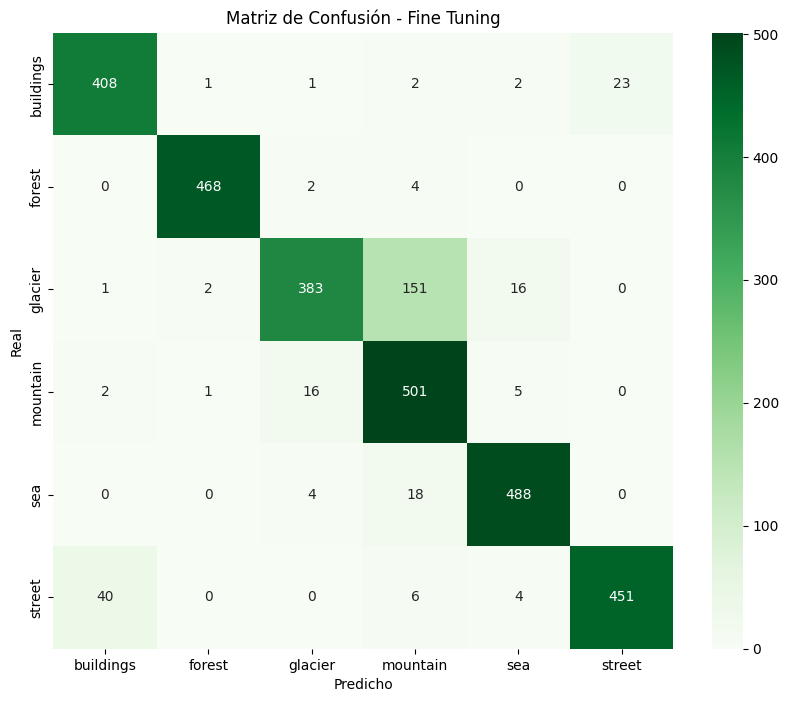

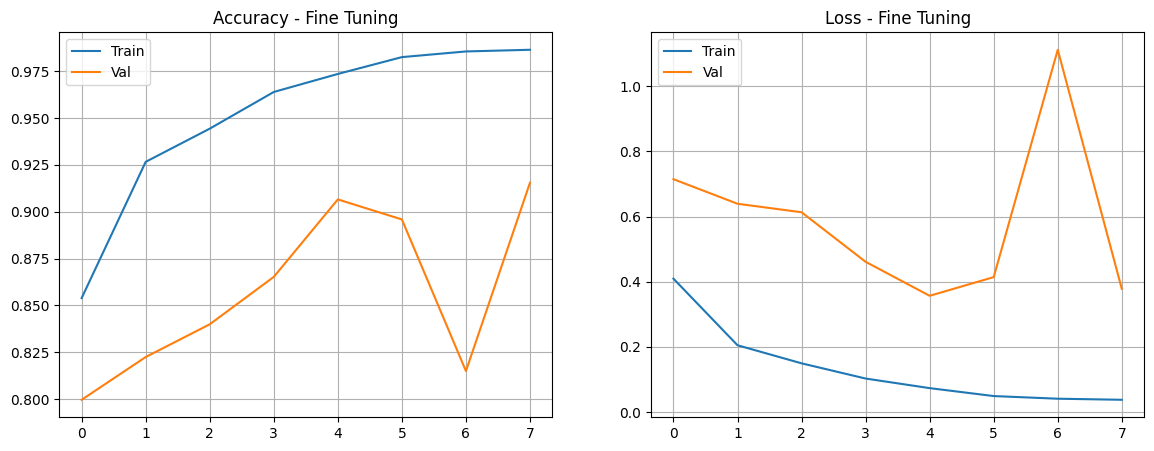

In [12]:
print("Evaluando Fine Tuning...")

test_loss_ft, test_acc_ft = model_ft.evaluate(test_generator)
print(f"\nTest Accuracy: {test_acc_ft:.4f}")

# Predicciones
y_pred_ft = model_ft.predict(test_generator)
y_pred_classes_ft = np.argmax(y_pred_ft, axis=1)

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes_ft, target_names=class_names))

# Matriz de confusión
cm_ft = confusion_matrix(y_true, y_pred_classes_ft)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_ft, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusión - Fine Tuning')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.show()

# Gráficas
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history_ft.history['accuracy'], label='Train')
ax1.plot(history_ft.history['val_accuracy'], label='Val')
ax1.set_title('Accuracy - Fine Tuning')
ax1.legend()
ax1.grid(True)

ax2.plot(history_ft.history['loss'], label='Train')
ax2.plot(history_ft.history['val_loss'], label='Val')
ax2.set_title('Loss - Fine Tuning')
ax2.legend()
ax2.grid(True)

plt.show()